In [2]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [3]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

In [4]:
step_size = 0.00164

l_mean_landscape = torch.load(f'L_mean_gridsize20_step{step_size}.pt')
l_mean_equiv = torch.load(f'L_equiv_gridsize20_step{step_size}.pt')

Plotting 3D landscape for L_mean...


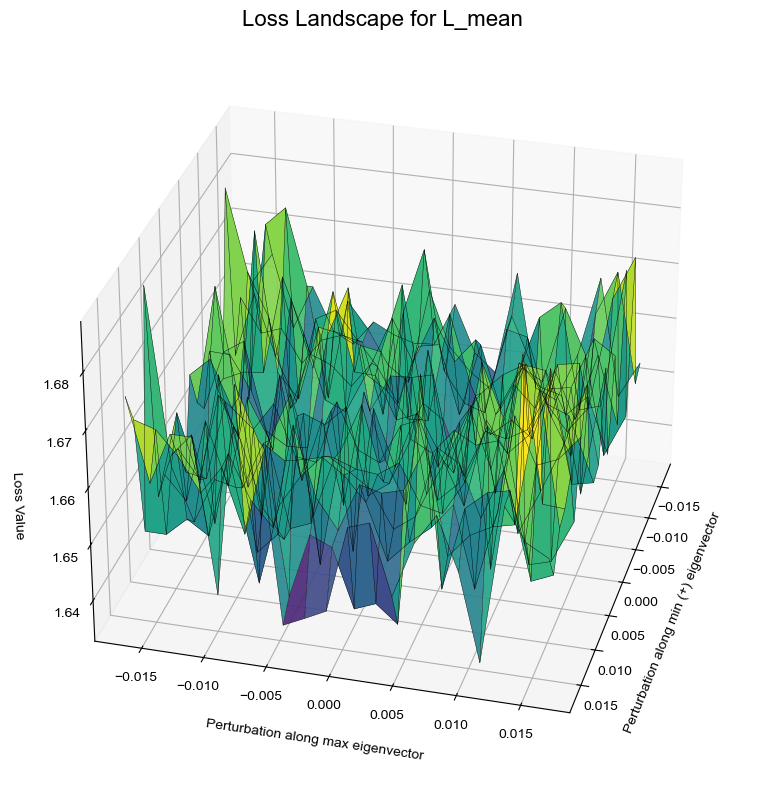

Plotting 3D landscape for L_equiv...


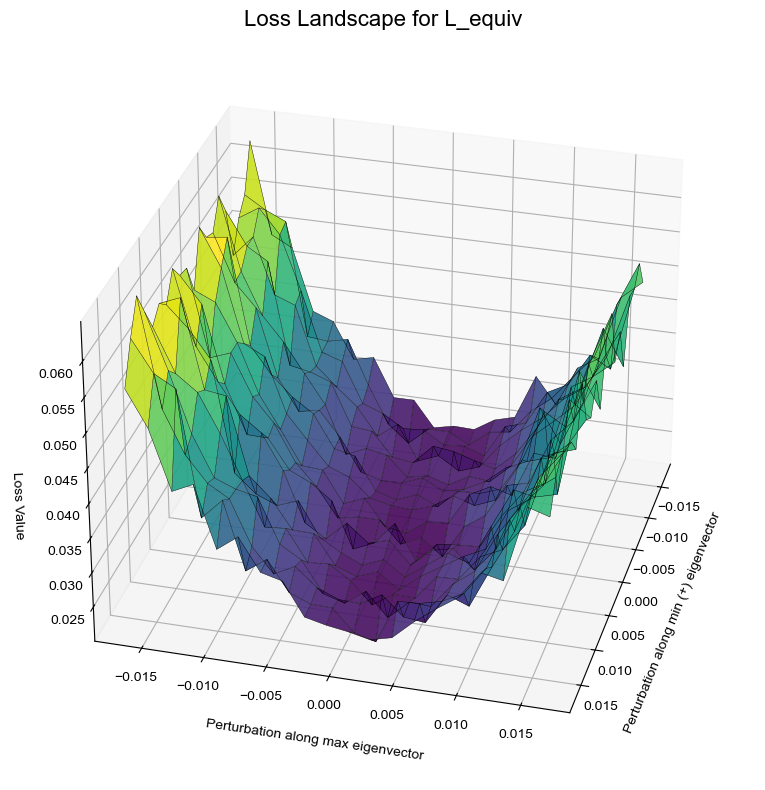

In [7]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm # For colormaps

# Loop through each loss in the dictionary

loss_landscape_dict = {
    'L_mean': l_mean_landscape,
    'L_equiv': l_mean_equiv,
}

for loss_name, landscape_tensor in loss_landscape_dict.items():
    print(f"Plotting 3D landscape for {loss_name}...")

    # Prepare data for plotting
    landscape_data = landscape_tensor.cpu().detach().numpy()
    grid_size = landscape_data.shape[0]

    # Create the coordinate grid required for a 3D surface plot
    x_coords = np.linspace(-step_size * grid_size / 2, step_size * grid_size / 2, grid_size)
    y_coords = np.linspace(-step_size * grid_size / 2, step_size * grid_size / 2, grid_size)
    # The meshgrid creates 2D arrays that form the base of the plot
    X, Y = np.meshgrid(x_coords, y_coords)

    # Create the 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface with a colormap
    # `rstride` and `cstride` control the wireframe density
    surf = ax.plot_surface(X, Y, landscape_data, cmap=cm.viridis,
                           linewidth=0.2, antialiased=True, alpha=0.9)
    
    # Add a wireframe for better structure visibility
    ax.plot_wireframe(X, Y, landscape_data, color='black', lw=0.3, rstride=1, cstride=1)

    # Mark the center point (original parameters)
    # center_index = grid_size // 2
    # center_loss = landscape_data[center_index, center_index]
    # ax.scatter(0, 0, center_loss, c='red', s=100, marker='X', depthshade=False, label='Original Parameters')
    # ax.legend()

    # Add a color bar which maps values to colors
    # fig.colorbar(surf, shrink=0.5, aspect=10, label='Loss Value')

    # Set labels and title
    ax.set_title(f'Loss Landscape for {loss_name}', fontsize=16)
    ax.set_xlabel('Perturbation along min (+) eigenvector', labelpad=10)
    ax.set_ylabel('Perturbation along max eigenvector', labelpad=10)
    ax.set_zlabel('Loss Value', labelpad=10)
    
    # You can adjust the viewing angle for better presentation
    # ax.view_init(elev=30, azim=-60) # elev=elevation, azim=azimuth
    # ax.view_init(elev=30, azim=30) # elev=elevation, azim=azimuth
    ax.view_init(elev=30, azim=15) # elev=elevation, azim=azimuth

    # --- 3. Save the plot to a file ---
    plot_name = f"loss_landscape_3D_{loss_name}_step{step_size}"

    import os
    os.makedirs('pdfs', exist_ok=True)

    plt.tight_layout()
    plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
    plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
    plt.show()
    plt.close()